# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph and node contexts.

In [6]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NodeContextConfig,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configure and run

In [7]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
ABSTRACT_PATH = ASSETS_ROOT / 'abstracts' / 'pathogen_abstract_nipah_virus.txt'
ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
DENSITY_PATH = ASSETS_ROOT / 'config' / 'extraction_density.json'
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'

abstract_text = load_text(ABSTRACT_PATH)
ontology = load_ontology(ONTOLOGY_PATH)
density = ExtractionDensityConfig.from_json_file(DENSITY_PATH)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    model='gpt-4o-mini',
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
)

graphicalizer = Graphicalizer.from_openai(ontology, config)
result = graphicalizer.run(abstract_text)

In [8]:
print('Model:', config.model)
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))

Model: gpt-4o-mini
Source SHA-256: 42466a9525771b6f88f34965debc73799d4e2e4e24ceb6ba20097bf948388589
Raw validation: {'valid': False, 'connected': False, 'sparse': True, 'node_count': 6, 'edge_count': 5, 'density': 0.3333333333333333, 'max_neighbor_count': 3, 'hub_nodes': ('e3',), 'issues': ('graph is disconnected', 'graph contains 1 hub node(s): e3'), 'density_ok': True, 'hubs_ok': False}
Normalized validation: {'valid': False, 'connected': True, 'sparse': False, 'node_count': 5, 'edge_count': 5, 'density': 0.5, 'max_neighbor_count': 3, 'hub_nodes': ('e3',), 'issues': ('graph density 0.500 exceeds 0.400', 'graph contains 1 hub node(s): e3'), 'density_ok': False, 'hubs_ok': False}
Normalization report: {'policy': 'largest_component', 'component_count': 2, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e5'), 'discarded_entity_ids': ('e6',), 'retained_relation_ids': ('r1', 'r2', 'r3', 'r4', 'r5'), 'discarded_relation_ids': ()}
Final validation: {'valid': False, 'connected': True, 'spars

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="pathogen\nNipah virus", shape=box];
  "e2" [label="reservoir_host\nPteropus bats", shape=box];
  "e3" [label="human_host\nhumans", shape=box];
  "e4" [label="contaminated_material\nraw date-palm sap", shape=box];
  "e5" [label="clinical_entity\nacute febrile encephalitis", shape=box];
  "e1" -> "e2" [color="#555555", label="maintained_in"];
  "e1" -> "e3" [color="#555555", label="causes_infection"];
  "e2" -> "e4" [color="#555555", label="contaminates"];
  "e4" -> "e3" [color="#555555", label="infects"];
  "e5" -> "e3" [color="#555555", label="presents_with"];
}



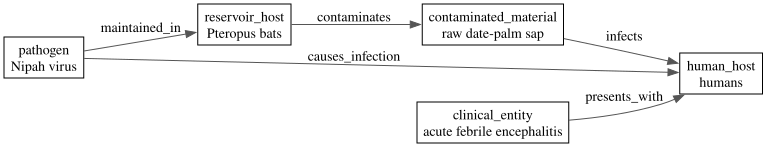

In [9]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Inspect node contexts

In [10]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {node_context.summary}')
    for evidence in node_context.evidence:
        print(f'  evidence: {evidence}')
    if node_context.uncertainty:
        print(f'  uncertainty: {node_context.uncertainty}')


[e1] Nipah virus is a zoonotic pathogen maintained in Pteropus bats that causes infections in humans, notably linked to severe neurological symptoms.
  evidence: Nipah virus infection was confirmed in patients with fever, altered mental status, and rapidly progressive encephalitis.
  evidence: Nipah virus is a zoonotic paramyxovirus maintained in populations of fruit bats of the genus Pteropus.

[e2] Pteropus bats serve as the reservoir host for Nipah virus, which can contaminate food sources like date-palm sap, posing a risk for human infection.
  evidence: Viral RNA was detected in residual sap and on protective coverings installed over collection vessels, and Nipah virus–reactive antibodies were detected in sampled Pteropus bats from the surrounding area.

[e3] Humans can become infected with Nipah virus, presenting with severe symptoms such as fever and encephalitis, primarily through contaminated food consumption.
  evidence: Nipah virus infection was confirmed in patients with f